
### **Markdown Cell 1**

```markdown
# Impact of COVID-19 on  Parcel Delivery Business
### 1. Environment Setup & Data Loading
This section imports the necessary libraries, loads the dataset, and defines the base pricing metrics required for the analysis.

```

### **Code Cell 1**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('COVID_Parcel_Business.csv')

# Base cost of sending a parcel without a contract
BASE_COST = 22.00

### **Markdown Cell 2**

```markdown
### 2. Descriptive Statistics
As per the executive requirements took shape, columns, and basic descriptive statistics of our parcel volumes.

```

### **Code Cell 2**

In [2]:
print("--- Dataset Information ---")
display(df.info())

print("\n--- Descriptive Statistics (Volume) ---")
display(df['VOLUME'].describe())

print("\n--- Available Years ---")
print(df['THE_YEAR'].unique())

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190719 entries, 0 to 190718
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   FakeCustomerID  190719 non-null  int64
 1   THE_YEAR        190719 non-null  int64
 2   THE_WEEK        190719 non-null  int64
 3   VOLUME          190719 non-null  int64
dtypes: int64(4)
memory usage: 5.8 MB


None


--- Descriptive Statistics (Volume) ---


,VOLUME
count,190719.000000
mean,1174.911519
std,11586.730666
min,1.000000
25%,25.000000
50%,58.000000
75%,162.000000
max,640590.000000



--- Available Years ---
[2021 2020 2019 2018]


### **Markdown Cell 3**

```markdown
### 3. Industry Standard Growth Rate (ISGR)
The ISGR establishes the baseline "normal" growth rate before the pandemic triggered massive shifts. We calculate this by comparing Week 1-15 of 2020 to Week 1-15 of 2019.

```

### **Code Cell 3**

In [3]:
# Extract volumes for Week 1 to 15 for both years
vol_2019_pre = df[(df['THE_YEAR'] == 2019) & (df['THE_WEEK'] >= 1) & (df['THE_WEEK'] <= 15)]['VOLUME'].sum()
vol_2020_pre = df[(df['THE_YEAR'] == 2020) & (df['THE_WEEK'] >= 1) & (df['THE_WEEK'] <= 15)]['VOLUME'].sum()

# Calculate ISGR: ((Current - Previous) / Previous) * 100
isgr = ((vol_2020_pre - vol_2019_pre) / vol_2019_pre) * 100

print(f"2019 Pre-COVID Volume: {vol_2019_pre:,.0f}")
print(f"2020 Pre-COVID Volume: {vol_2020_pre:,.0f}")
print(f"Industry Standard Growth Rate (ISGR): {isgr:.2f}%")

2019 Pre-COVID Volume: 13,122,816
2020 Pre-COVID Volume: 14,619,017
Industry Standard Growth Rate (ISGR): 11.40%


### **Markdown Cell 4**

```markdown
### 4. Customer Segmentation & Revenue Calculation
Discounts and groupings are assigned based on a customer's **2019 parcel volume**. We will aggregate the 2019 data, assign the appropriate tiers, and then calculate the revenue across the entire dataframe.

```

### **Code Cell 4**

In [4]:
# Calculate 2019 volumes per customer
vol_2019_cust = df[df['THE_YEAR'] == 2019].groupby('FakeCustomerID')['VOLUME'].sum().reset_index()

# Function to assign segments based on the rubric parameters
def assign_segment(vol):
    if vol > 500000: return 'Enterprise', 0.22
    elif vol >= 200000: return 'Large', 0.17
    elif vol >= 10000: return 'Medium', 0.10
    elif vol >= 1000: return 'Small', 0.04
    else: return 'Micro', 0.00 # For those under 1k

# Apply segment and discount mapping to the 2019 data
vol_2019_cust[['Customer Size', 'Discount']] = vol_2019_cust['VOLUME'].apply(lambda x: pd.Series(assign_segment(x)))

# Merge these customer segments back into the main dataframe
df = df.merge(vol_2019_cust[['FakeCustomerID', 'Customer Size', 'Discount']], on='FakeCustomerID', how='left')

# For completely new customers (who did not exist in 2019), fill their blanks
df['Customer Size'] = df['Customer Size'].fillna('New Customer')
df['Discount'] = df['Discount'].fillna(0.0)

# Calculate final revenue (Volume * Base Cost * (1 - Discount))
df['Revenue'] = df['VOLUME'] * BASE_COST * (1 - df['Discount'])

print("Dataframe successfully updated with Segments and Revenue.")
display(df.head())

Dataframe successfully updated with Segments and Revenue.


,FakeCustomerID,THE_YEAR,THE_WEEK,VOLUME,Customer Size,Discount,Revenue
0,718117,2021,1,8,Small,0.04,168.96
1,718117,2020,7,257,Small,0.04,5427.84
2,718117,2019,39,141,Small,0.04,2977.92
3,718117,2018,1,14,Small,0.04,295.68
4,718117,2021,2,192,Small,0.04,4055.04


### **Markdown Cell 5**

```markdown
### 5. Visualizations (Line, Bar, and Pie Charts)
Here we will answer the specific visual business questions: weekly timelines, peak season impacts, and overall revenue segmentation.

```

### **Code Cell 5**

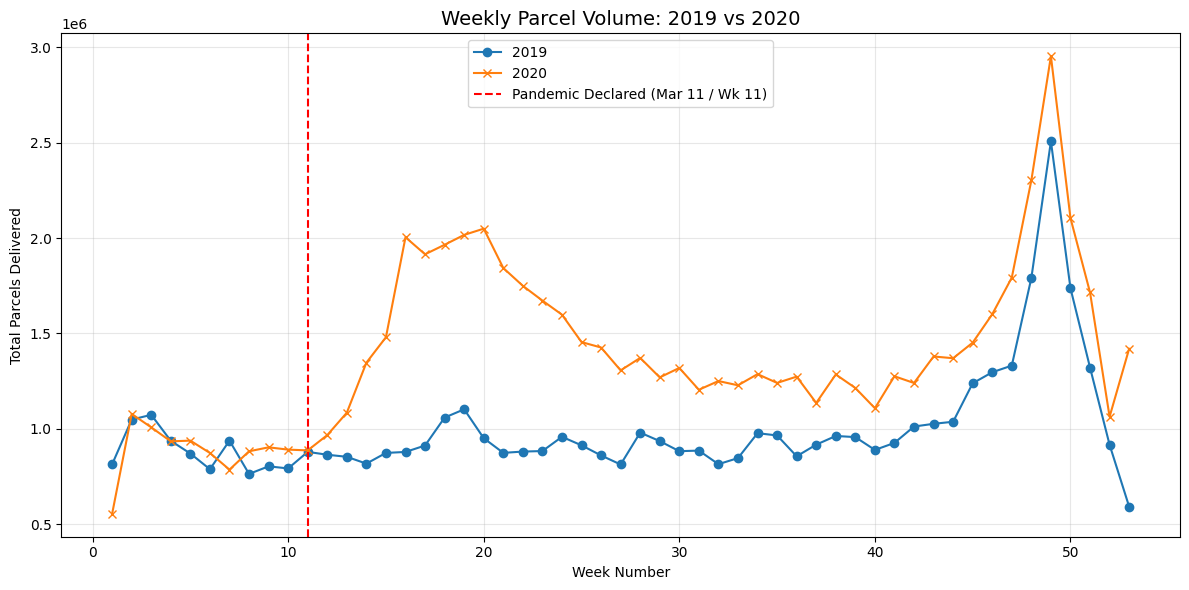

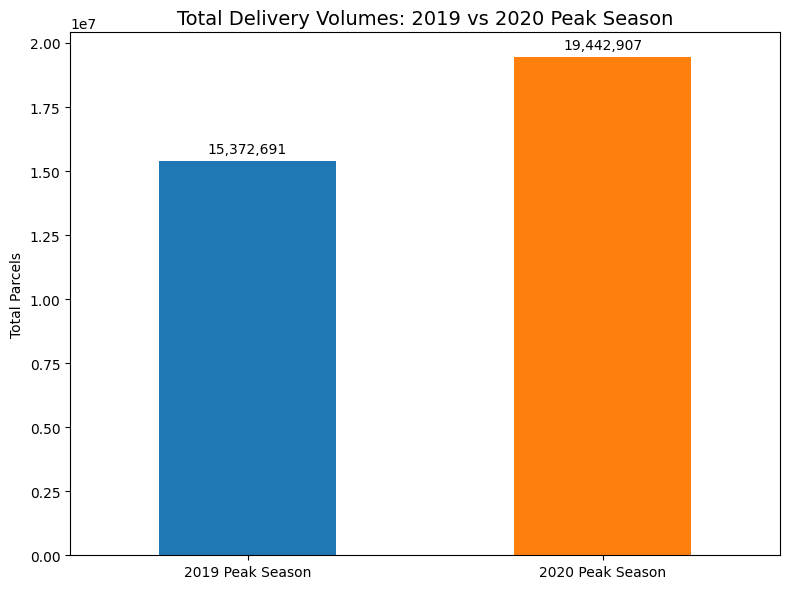

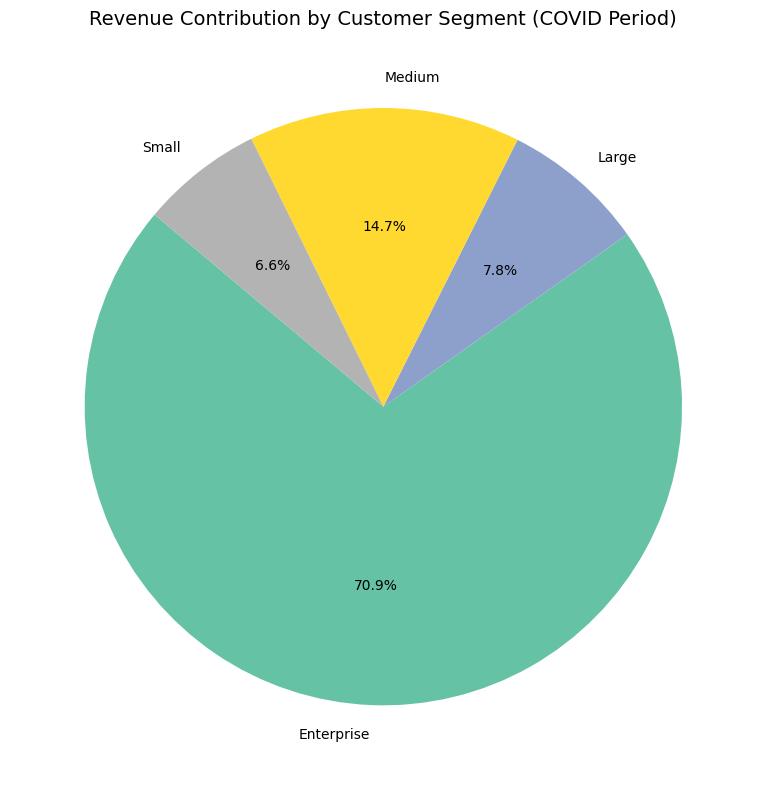

In [5]:
# --- 1. Line Chart: Weekly Volume Trend ---
weekly_vol = df.groupby(['THE_YEAR', 'THE_WEEK'])['VOLUME'].sum().reset_index()
weekly_2019 = weekly_vol[weekly_vol['THE_YEAR'] == 2019]
weekly_2020 = weekly_vol[weekly_vol['THE_YEAR'] == 2020]

plt.figure(figsize=(12, 6))
plt.plot(weekly_2019['THE_WEEK'], weekly_2019['VOLUME'], label='2019', marker='o')
plt.plot(weekly_2020['THE_WEEK'], weekly_2020['VOLUME'], label='2020', marker='x')
plt.axvline(x=11, color='red', linestyle='--', label='Pandemic Declared (Mar 11 / Wk 11)')
plt.title('Weekly Parcel Volume: 2019 vs 2020', fontsize=14)
plt.xlabel('Week Number')
plt.ylabel('Total Parcels Delivered')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- 2. Bar Chart: Impact on Peak Season ---
# 2019 Peak: Nov 2019 (Week 45) to Jan 2020 (Week 3)
peak_2019 = df[((df['THE_YEAR'] == 2019) & (df['THE_WEEK'] >= 45)) |
               ((df['THE_YEAR'] == 2020) & (df['THE_WEEK'] <= 3))]['VOLUME'].sum()

# 2020 Peak: Nov 2020 (Week 45) to Jan 2021 (Week 3)
peak_2020 = df[((df['THE_YEAR'] == 2020) & (df['THE_WEEK'] >= 45)) |
               ((df['THE_YEAR'] == 2021) & (df['THE_WEEK'] <= 3))]['VOLUME'].sum()

peak_comparison = pd.Series({'2019 Peak Season': peak_2019, '2020 Peak Season': peak_2020})

plt.figure(figsize=(8, 6))
bars = peak_comparison.plot(kind='bar', color=['#1f77b4', '#ff7f0e'])
plt.title('Total Delivery Volumes: 2019 vs 2020 Peak Season', fontsize=14)
plt.ylabel('Total Parcels')
plt.xticks(rotation=0)

# Add data labels on top of bars
for p in bars.patches:
    bars.annotate(format(p.get_height(), ',.0f'),
                  (p.get_x() + p.get_width() / 2., p.get_height()),
                  ha='center', va='center', xytext=(0, 9), textcoords='offset points')
plt.tight_layout()
plt.show()

# --- 3. Pie Chart: Overall Revenue by Customer Group during COVID ---
# Isolate the COVID Observation period (Week 11 to 53, 2020)
covid_period = df[(df['THE_YEAR'] == 2020) & (df['THE_WEEK'] >= 11) & (df['THE_WEEK'] <= 53)]
revenue_by_size = covid_period.groupby('Customer Size')['Revenue'].sum()

plt.figure(figsize=(8, 8))
revenue_by_size.plot(kind='pie', autopct='%1.1f%%', startangle=140, cmap='Set2')
plt.title('Revenue Contribution by Customer Segment (COVID Period)', fontsize=14)
plt.ylabel('')
plt.tight_layout()
plt.show()

### **Markdown Cell 6**

```markdown
### 6. The Impact of COVID on Customer Segments (Growth Status)
To answer what percentage of each group is growing, stable, declining, new, or lost, we compare individual customer performance during the COVID period against the exact same timeline from 2019.

```

### **Code Cell 6**

Percentage Breakdown of Customer Status by Segment:


Status,Declining,High Growth,Lost Customer,Stable
Customer Size,,,,
Enterprise,33.33,66.67,0.00,0.00
Large,13.33,66.67,0.00,20.00
Medium,38.51,51.15,0.57,9.77
Small,35.16,55.53,2.56,6.75


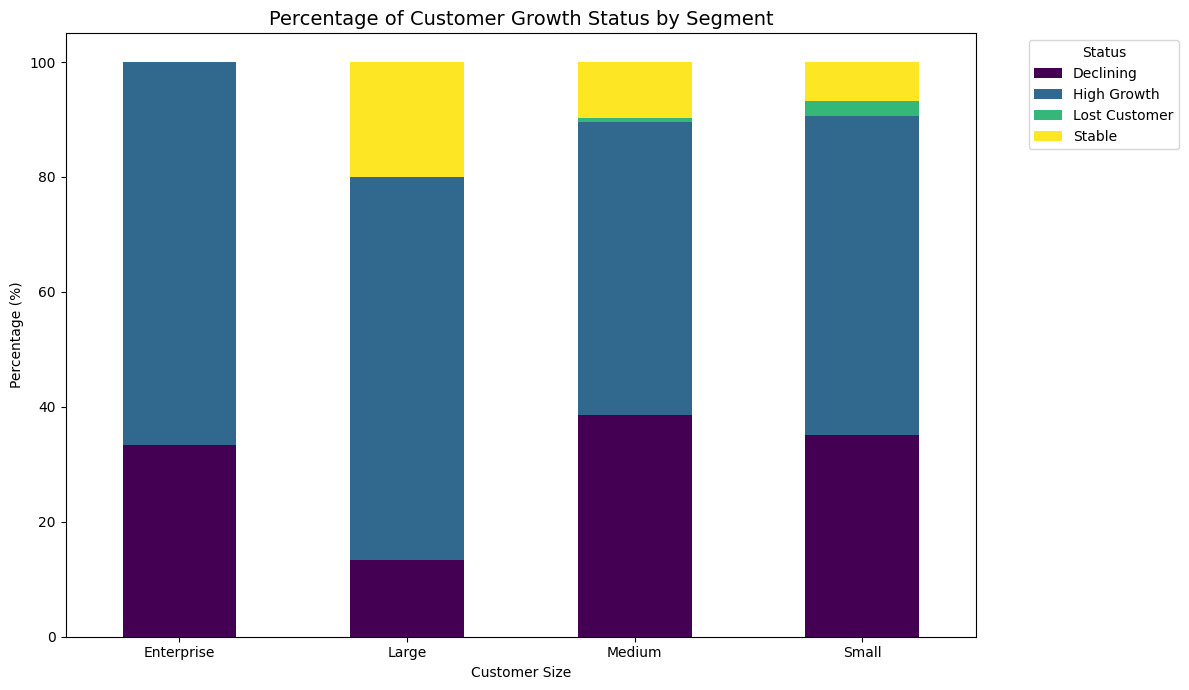

In [6]:
# Pre-COVID Equivalent Period (Week 11 to Week 53, 2019)
precovid_period = df[(df['THE_YEAR'] == 2019) & (df['THE_WEEK'] >= 11) & (df['THE_WEEK'] <= 53)]

# Aggregate volumes per customer for these periods
vol_covid_cust = covid_period.groupby(['FakeCustomerID', 'Customer Size'])['VOLUME'].sum().reset_index()
vol_precovid_cust = precovid_period.groupby(['FakeCustomerID', 'Customer Size'])['VOLUME'].sum().reset_index()

# Merge pre-covid and covid periods
cust_status = pd.merge(vol_precovid_cust, vol_covid_cust, on=['FakeCustomerID', 'Customer Size'], how='outer', suffixes=('_pre', '_covid'))
cust_status = cust_status.fillna(0) # Fill NaNs with 0 for pure tracking of lost/new

# Calculate Individual Growth Rate
cust_status['Growth_Rate'] = np.where(
    cust_status['VOLUME_pre'] == 0,
    np.inf, # Infinite growth if they had 0 volume previously
    ((cust_status['VOLUME_covid'] - cust_status['VOLUME_pre']) / cust_status['VOLUME_pre']) * 100
)

# Apply categorization logic based on the ISGR (11.40%)
def determine_status(row):
    pre = row['VOLUME_pre']
    covid = row['VOLUME_covid']
    gr = row['Growth_Rate']

    if pre == 0 and covid > 0:
        return 'New Customer'
    elif pre > 0 and covid == 0:
        return 'Lost Customer'
    elif gr > isgr:
        return 'High Growth'
    elif 0 <= gr <= isgr:
        return 'Stable'
    elif gr < 0:
        return 'Declining'
    else:
        return 'Other'

cust_status['Status'] = cust_status.apply(determine_status, axis=1)

# Generate Percentage Crosstab Table
status_pct = pd.crosstab(cust_status['Customer Size'], cust_status['Status'], normalize='index') * 100

print("Percentage Breakdown of Customer Status by Segment:")
display(status_pct.round(2))

# Visualize the breakdown
ax = status_pct.plot(kind='bar', stacked=True, figsize=(12, 7), cmap='viridis')
plt.title('Percentage of Customer Growth Status by Segment', fontsize=14)
plt.ylabel('Percentage (%)')
plt.xlabel('Customer Size')
plt.xticks(rotation=0)
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()